In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

**i. IMPORTS & GPU SETUP**

In [55]:
# ============================================
# i. IMPORTS & GPU SETUP
# ============================================

import numpy as np
import pandas as pd
import torch
import os
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import DBSCAN
from sklearn.feature_extraction.text import TfidfVectorizer
from transformers import CLIPProcessor, CLIPModel
import textwrap
import warnings
warnings.filterwarnings('ignore')

# Set high DPI for print-quality images
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Using device: {device}")

✅ Using device: cuda


**ii. LOAD DATASET**

In [56]:
# ============================================
# ii. LOAD DATASET
# ============================================

print("\n" + "="*50)
print("📂 LOADING DATASET")
print("="*50)

possible_paths = [
    '/kaggle/input/datasets/paramaggarwal/fashion-product-images-small/styles.csv',
    '/kaggle/input/datasets/paramaggarwal/fashion-product-images-small/myntradataset/styles.csv',
    '/kaggle/input/datasets/sahandakramipour/data-labels-fashion-product-images-small/data_labels.csv'
]

df = None
for path in possible_paths:
    if os.path.exists(path):
        df = pd.read_csv(path, on_bad_lines='skip')
        print(f"✅ Loaded: {path}")
        break
if df is None:
    raise FileNotFoundError("Dataset not found!")

print(f"📊 Total rows: {len(df)}")
print(f"📋 Columns: {df.columns.tolist()}")


📂 LOADING DATASET
✅ Loaded: /kaggle/input/datasets/paramaggarwal/fashion-product-images-small/styles.csv
📊 Total rows: 44424
📋 Columns: ['id', 'gender', 'masterCategory', 'subCategory', 'articleType', 'baseColour', 'season', 'year', 'usage', 'productDisplayName']


**iii. DATA CLEANING**

In [57]:
# ============================================
# iii. DATA CLEANING
# ============================================

print("\n" + "="*50)
print("🧹 DATA CLEANING")
print("="*50)

if 'productDisplayName' not in df.columns:
    df['productDisplayName'] = df['baseColour'] + ' ' + df['articleType']

if df['masterCategory'].dtype in ['int64', 'float64']:
    mapping = {1: 'Men', 2: 'Women', 3: 'Kids'}
    df['category'] = df['masterCategory'].map(mapping)
else:
    df['category'] = df['masterCategory']

image_dir = '/kaggle/input/datasets/paramaggarwal/fashion-product-images-small/images'
if os.path.exists(image_dir):
    image_files = os.listdir(image_dir)
    image_ids = set()
    for f in image_files:
        try:
            image_ids.add(int(f.replace('.jpg', '')))
        except:
            continue
    df['image_path'] = df['id'].apply(lambda x: os.path.join(image_dir, f"{x}.jpg") if x in image_ids else None)
    df = df[df['image_path'].notna()].reset_index(drop=True)
    print(f"🖼️ Products with images: {len(df)}")
else:
    print("⚠️ Image directory not found. Using dummy paths.")

print("\n📊 Dataset Info:")
print(f"   - Total products: {len(df)}")
print(f"   - Categories: {df['category'].unique().tolist()}")
print(f"   - Subcategories: {df['subCategory'].nunique()}")
print("\n🔍 Sample:")
print(df[['id', 'productDisplayName', 'category', 'subCategory']].head())



🧹 DATA CLEANING
🖼️ Products with images: 44419

📊 Dataset Info:
   - Total products: 44419
   - Categories: ['Apparel', 'Accessories', 'Footwear', 'Personal Care', 'Free Items', 'Sporting Goods', 'Home']
   - Subcategories: 45

🔍 Sample:
      id                             productDisplayName     category  \
0  15970               Turtle Check Men Navy Blue Shirt      Apparel   
1  39386             Peter England Men Party Blue Jeans      Apparel   
2  59263                       Titan Women Silver Watch  Accessories   
3  21379  Manchester United Men Solid Black Track Pants      Apparel   
4  53759                          Puma Men Grey T-shirt      Apparel   

  subCategory  
0     Topwear  
1  Bottomwear  
2     Watches  
3  Bottomwear  
4     Topwear  


**iv. LOAD CLIP MODEL**

In [58]:
# ============================================
# iv. LOAD CLIP MODEL
# ============================================

print("\n" + "="*50)
print("🤖 LOADING CLIP MODEL")
print("="*50)

model_name = "openai/clip-vit-base-patch32"
processor = CLIPProcessor.from_pretrained(model_name)
model = CLIPModel.from_pretrained(model_name).to(device)
model.eval()
print("✅ CLIP model loaded.")


🤖 LOADING CLIP MODEL


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ CLIP model loaded.


**v. GENERATE EMBEDDINGS**

In [59]:
# ============================================
# v. GENERATE EMBEDDINGS
# ============================================

print("\n" + "="*50)
print("🔢 GENERATING EMBEDDINGS")
print("="*50)

sample_size = min(5000, len(df))  # change to len(df) for full dataset
df_subset = df.sample(n=sample_size, random_state=42).reset_index(drop=True)
print(f"📊 Processing {len(df_subset)} products...")

def get_text_embeddings(texts, batch_size=32):
    all_emb = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        inputs = processor(text=batch, return_tensors="pt", padding=True, truncation=True, max_length=77).to(device)
        with torch.no_grad():
            emb = model.get_text_features(**inputs)
            if hasattr(emb, 'pooler_output'):
                emb = emb.pooler_output
            elif isinstance(emb, tuple):
                emb = emb[0]
        all_emb.append(emb.cpu().numpy())
    return np.vstack(all_emb)

def get_image_embeddings(paths, batch_size=16):
    all_emb = []
    for i in range(0, len(paths), batch_size):
        batch_paths = paths[i:i+batch_size]
        images = []
        for p in batch_paths:
            try:
                if p and os.path.exists(p):
                    images.append(Image.open(p).convert('RGB'))
                else:
                    images.append(Image.new('RGB', (224,224), color='gray'))
            except:
                images.append(Image.new('RGB', (224,224), color='gray'))
        inputs = processor(images=images, return_tensors="pt", padding=True).to(device)
        with torch.no_grad():
            emb = model.get_image_features(**inputs)
            if hasattr(emb, 'pooler_output'):
                emb = emb.pooler_output
            elif isinstance(emb, tuple):
                emb = emb[0]
        all_emb.append(emb.cpu().numpy())
    return np.vstack(all_emb)

texts = df_subset['productDisplayName'].fillna('').tolist()
text_emb = get_text_embeddings(texts, batch_size=32)
image_emb = get_image_embeddings(df_subset['image_path'].tolist(), batch_size=16)

text_emb = text_emb / np.linalg.norm(text_emb, axis=1, keepdims=True)
image_emb = image_emb / np.linalg.norm(image_emb, axis=1, keepdims=True)
embeddings = (text_emb + image_emb) / 2
print(f"✅ Embeddings shape: {embeddings.shape}")


🔢 GENERATING EMBEDDINGS
📊 Processing 5000 products...
✅ Embeddings shape: (5000, 512)


**vi. DISPLAY HELPER** 

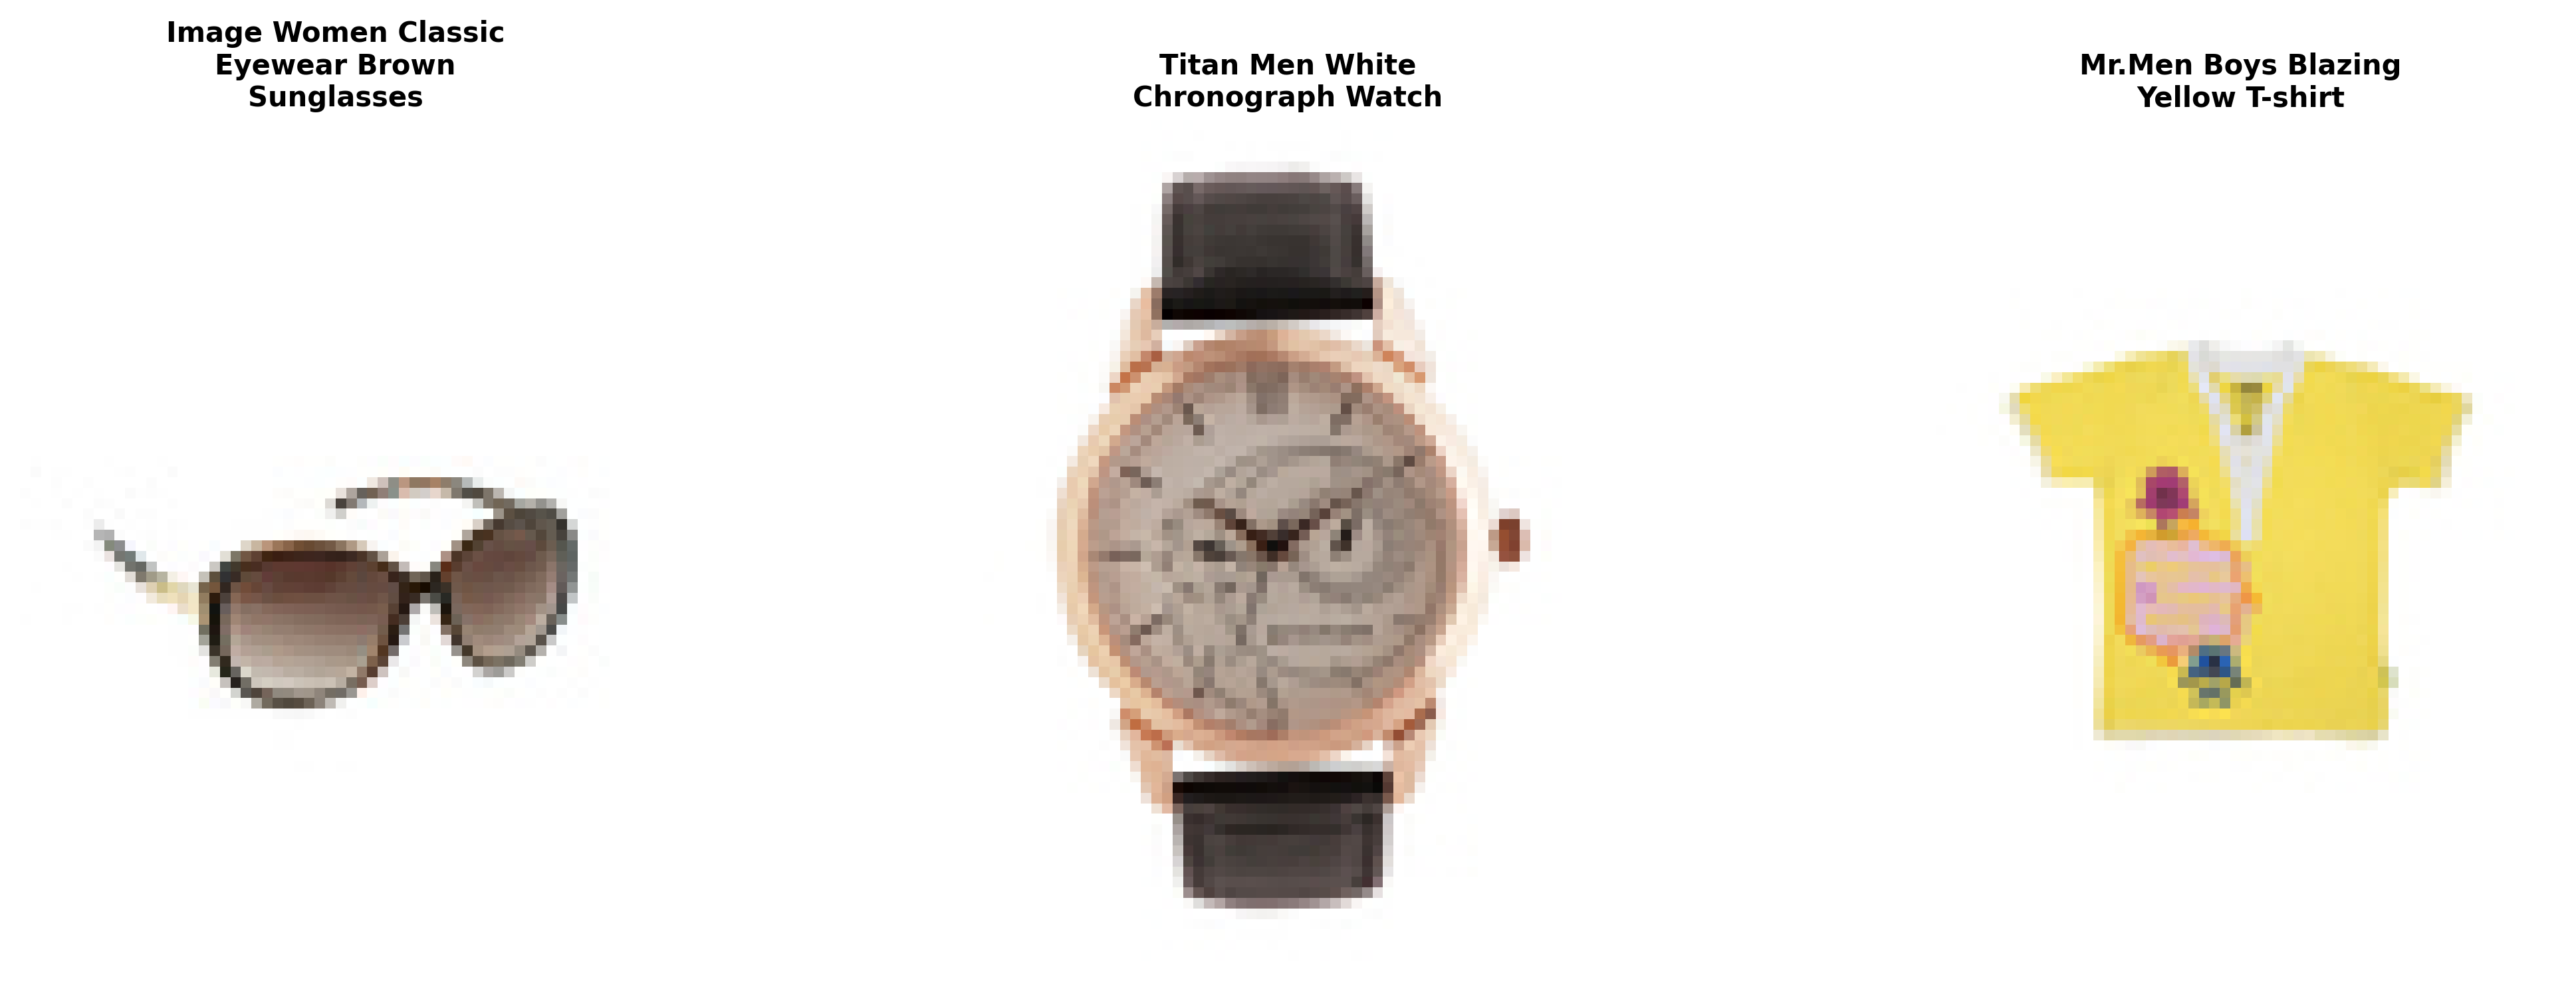

In [67]:
%matplotlib inline
import textwrap

def display_images(product_ids, titles=None, subtitles=None, cols=3, figsize=(20,12)):
    """Display images with wrapped titles to avoid overlap."""
    n = len(product_ids)
    rows = (n + cols - 1) // cols
    fig = plt.figure(figsize=figsize, dpi=300)
    for i, pid in enumerate(product_ids):
        if i >= rows * cols:
            break
        ax = fig.add_subplot(rows, cols, i+1)
        row = df_subset[df_subset['id'] == pid]
        if len(row) == 0:
            ax.text(0.5,0.5,"Not found", ha='center', va='center')
            ax.axis('off')
            continue
        img_path = row.iloc[0]['image_path']
        if img_path and os.path.exists(img_path):
            img = Image.open(img_path)
            ax.imshow(img)
        else:
            ax.text(0.5,0.5,"No Image", ha='center', va='center')
        # Title with wrapping
        if titles and i < len(titles):
            wrapped = "\n".join(textwrap.wrap(titles[i], width=20))
            ax.set_title(wrapped, fontsize=10, fontweight='bold', pad=5)
        if subtitles and i < len(subtitles):
            ax.set_xlabel(subtitles[i], fontsize=8)
        ax.axis('off')
    for j in range(n, rows*cols):
        fig.add_subplot(rows, cols, j+1).axis('off')
    plt.tight_layout(pad=1.0)
    plt.show()

# Test with 3 products
test_ids = df_subset['id'].head(3).tolist()
test_titles = df_subset['productDisplayName'].head(3).tolist()
display_images(test_ids, titles=test_titles, cols=3, figsize=(15,5))

**TASK 1: Smart Product Recommendation Engine**


🎯 TASK 1: SMART PRODUCT RECOMMENDATION ENGINE

🔍 EXAMPLE: Input 'Black boys shoes'
✅ Found product: ADIDAS Men Furano 3 M Black Sports Shoes (ID: 15310)


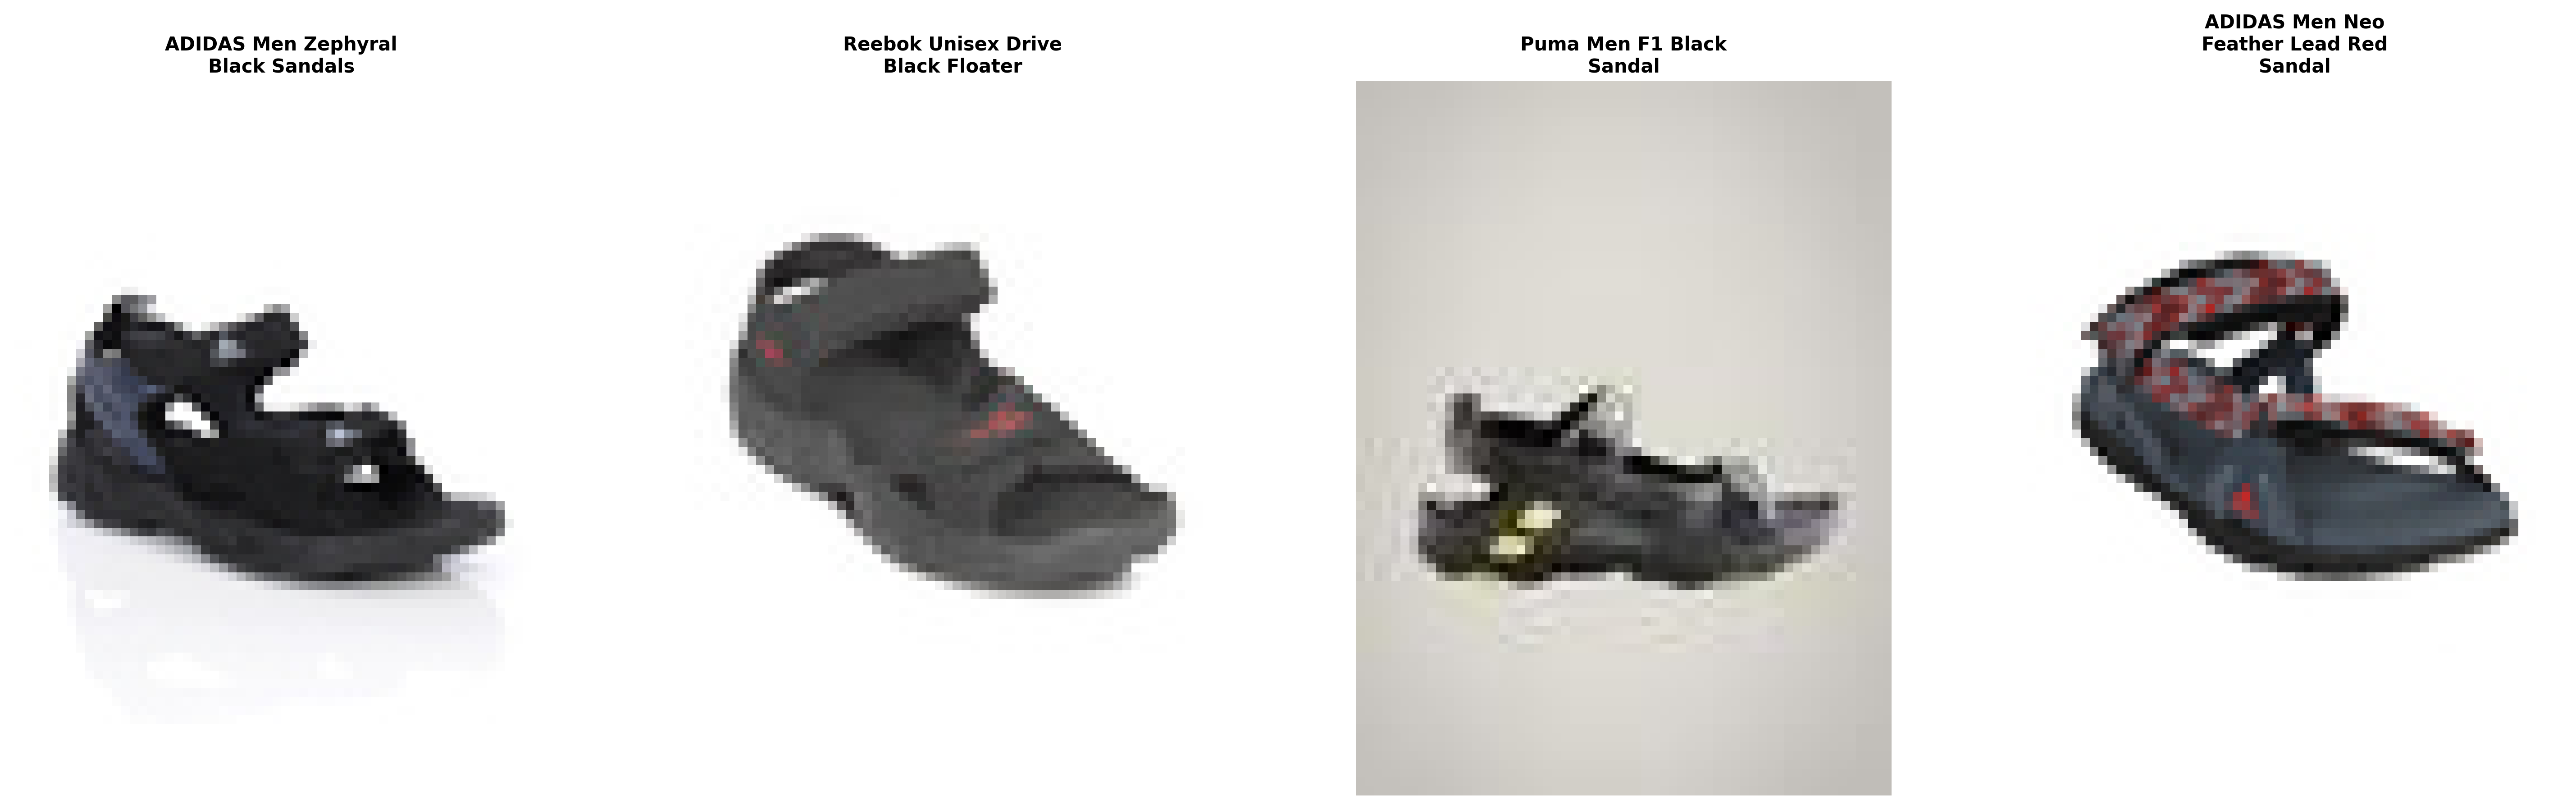

In [70]:
# ============================================
# TASK 1: Smart Product Recommendation Engine
# ============================================

print("\n" + "="*50)
print("🎯 TASK 1: SMART PRODUCT RECOMMENDATION ENGINE")
print("="*50)

similarity_matrix = cosine_similarity(embeddings)

def recommend_complementary(product_id_or_name, top_k=4):
    if isinstance(product_id_or_name, str):
        matches = df_subset[df_subset['productDisplayName'].str.lower().str.contains(product_id_or_name.lower(), na=False)]
        if len(matches) == 0:
            print(f"❌ No product found for '{product_id_or_name}'")
            return []
        idx = matches.index[0]
    else:
        try:
            idx = df_subset[df_subset['id'] == product_id_or_name].index[0]
        except:
            print(f"❌ Product ID {product_id_or_name} not found")
            return []

    product_subcat = df_subset.iloc[idx]['subCategory']
    scores = similarity_matrix[idx]
    penalty = np.ones(len(df_subset))
    same_subcat = (df_subset['subCategory'] == product_subcat)
    penalty[same_subcat] = 0.1
    penalty[idx] = 0
    adjusted = scores * penalty
    top_indices = adjusted.argsort()[::-1][:top_k*2]
    rec_ids = []
    for i in top_indices:
        if adjusted[i] > 0.05 and df_subset.iloc[i]['subCategory'] != product_subcat:
            rec_ids.append(df_subset.iloc[i]['id'])
        if len(rec_ids) == top_k:
            break
    return rec_ids

print("\n🔍 EXAMPLE: Input 'Black boys shoes'")
shoe_products = df_subset[df_subset['productDisplayName'].str.lower().str.contains('running|sneaker|sport', na=False)]
if len(shoe_products) > 0:
    shoe_id = shoe_products.iloc[0]['id']
    shoe_name = shoe_products.iloc[0]['productDisplayName']
    print(f"✅ Found product: {shoe_name} (ID: {shoe_id})")
    recs = recommend_complementary(shoe_id, top_k=4)
    if recs:
        titles = [df_subset[df_subset['id']==pid].iloc[0]['productDisplayName'] for pid in recs]
        subtitles = [df_subset[df_subset['id']==pid].iloc[0]['subCategory'] for pid in recs]
        display_images(recs, titles=titles, subtitles=subtitles, cols=4, figsize=(20,6))
    else:
        print("No recommendations.")
else:
    print("No shoe product found.")

**TASK 2:Unique Product Catalog Creation**


🧹 TASK 2: UNIQUE PRODUCT CATALOG
✅ Unique catalog size: 1457 (from 5000)


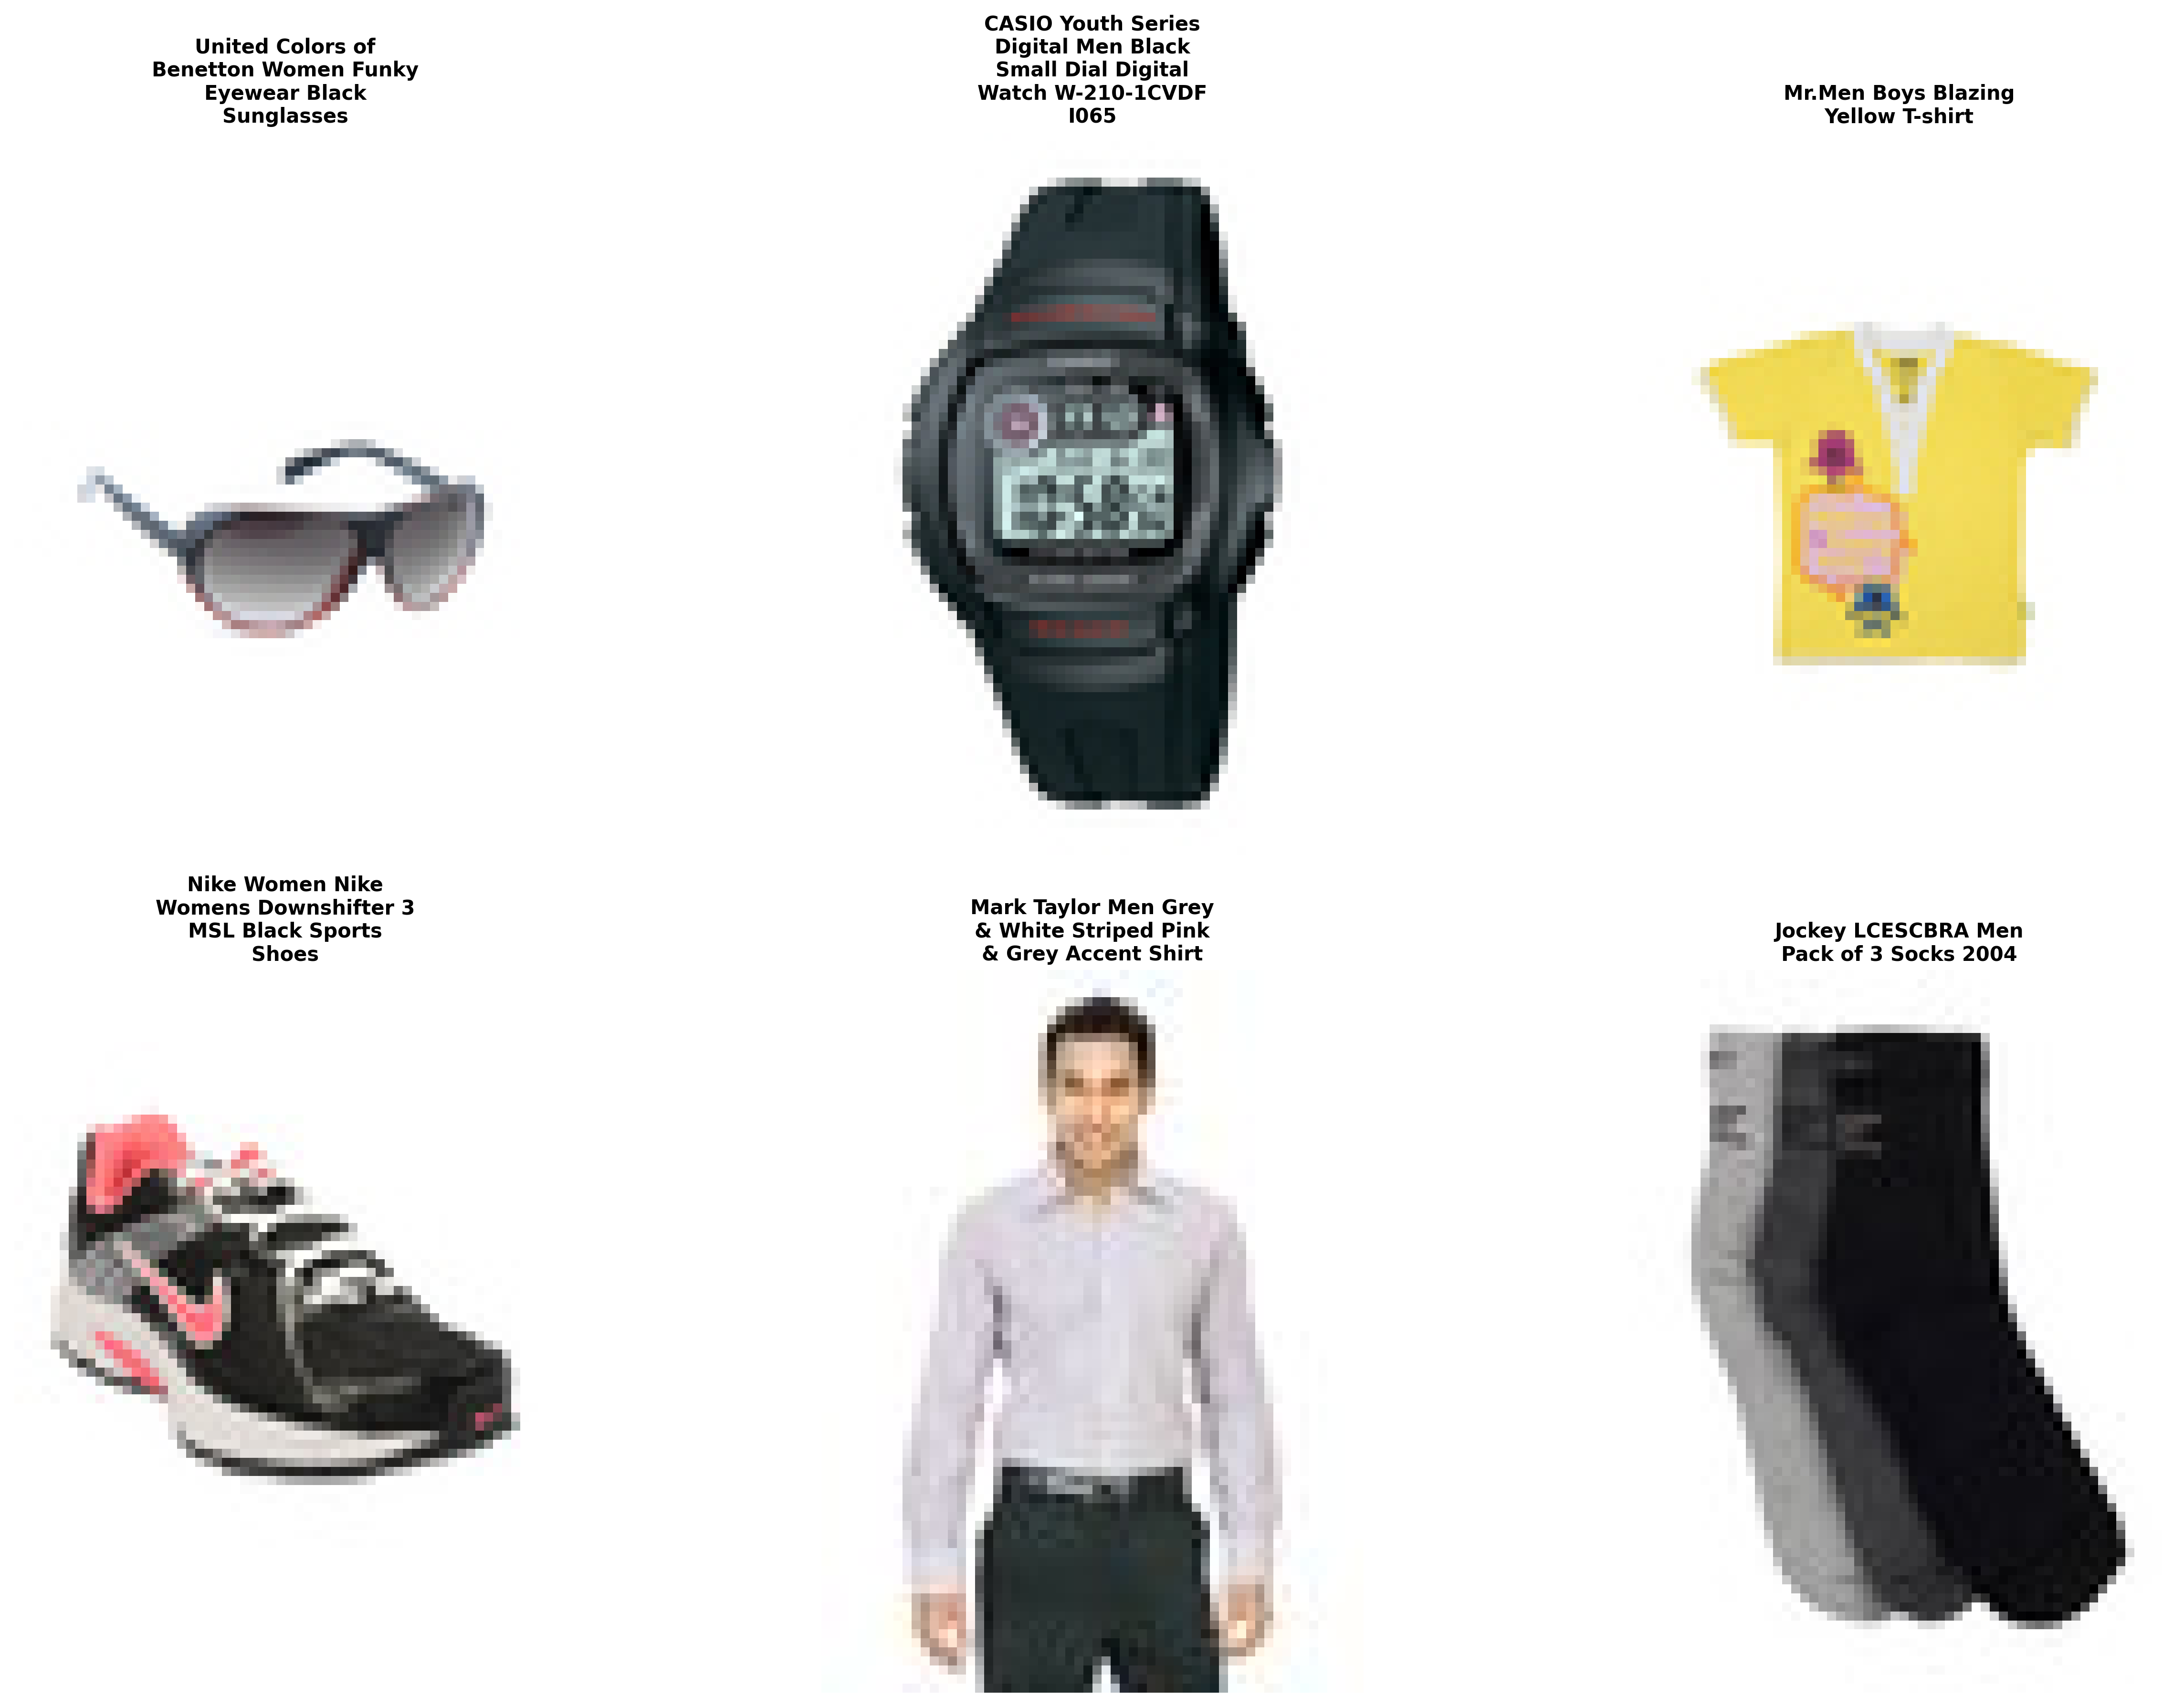

In [63]:
# ============================================
# TASK 2:Unique Product Catalog Creation
# ============================================

print("\n" + "="*50)
print("🧹 TASK 2: UNIQUE PRODUCT CATALOG")
print("="*50)

def create_unique_catalog(embeddings, similarity_threshold=0.90):
    eps = 1 - similarity_threshold
    clustering = DBSCAN(eps=eps, min_samples=2, metric='cosine')
    labels = clustering.fit_predict(embeddings)
    groups = {}
    for idx, label in enumerate(labels):
        if label != -1:
            groups.setdefault(label, []).append(idx)
    representative_ids = []
    for group in groups.values():
        scores = []
        for idx in group:
            name = df_subset.iloc[idx]['productDisplayName']
            score = len(str(name)) + (10 if pd.notna(df_subset.iloc[idx].get('category')) else 0)
            scores.append(score)
        best_idx = group[np.argmax(scores)]
        representative_ids.append(df_subset.iloc[best_idx]['id'])
    noise_indices = [i for i,l in enumerate(labels) if l == -1]
    for idx in noise_indices:
        representative_ids.append(df_subset.iloc[idx]['id'])
    return representative_ids

unique_ids = create_unique_catalog(embeddings, similarity_threshold=0.90)
print(f"✅ Unique catalog size: {len(unique_ids)} (from {len(df_subset)})")
titles = [df_subset[df_subset['id']==pid].iloc[0]['productDisplayName'] for pid in unique_ids[:6]]
display_images(unique_ids[:6], titles=titles, cols=3, figsize=(18,12))

**TASK 3: Reverse Product Search**


🔍 TASK 3: REVERSE PRODUCT SEARCH (CLIP semantic)

🔎 Query: 'blue casual shirt'


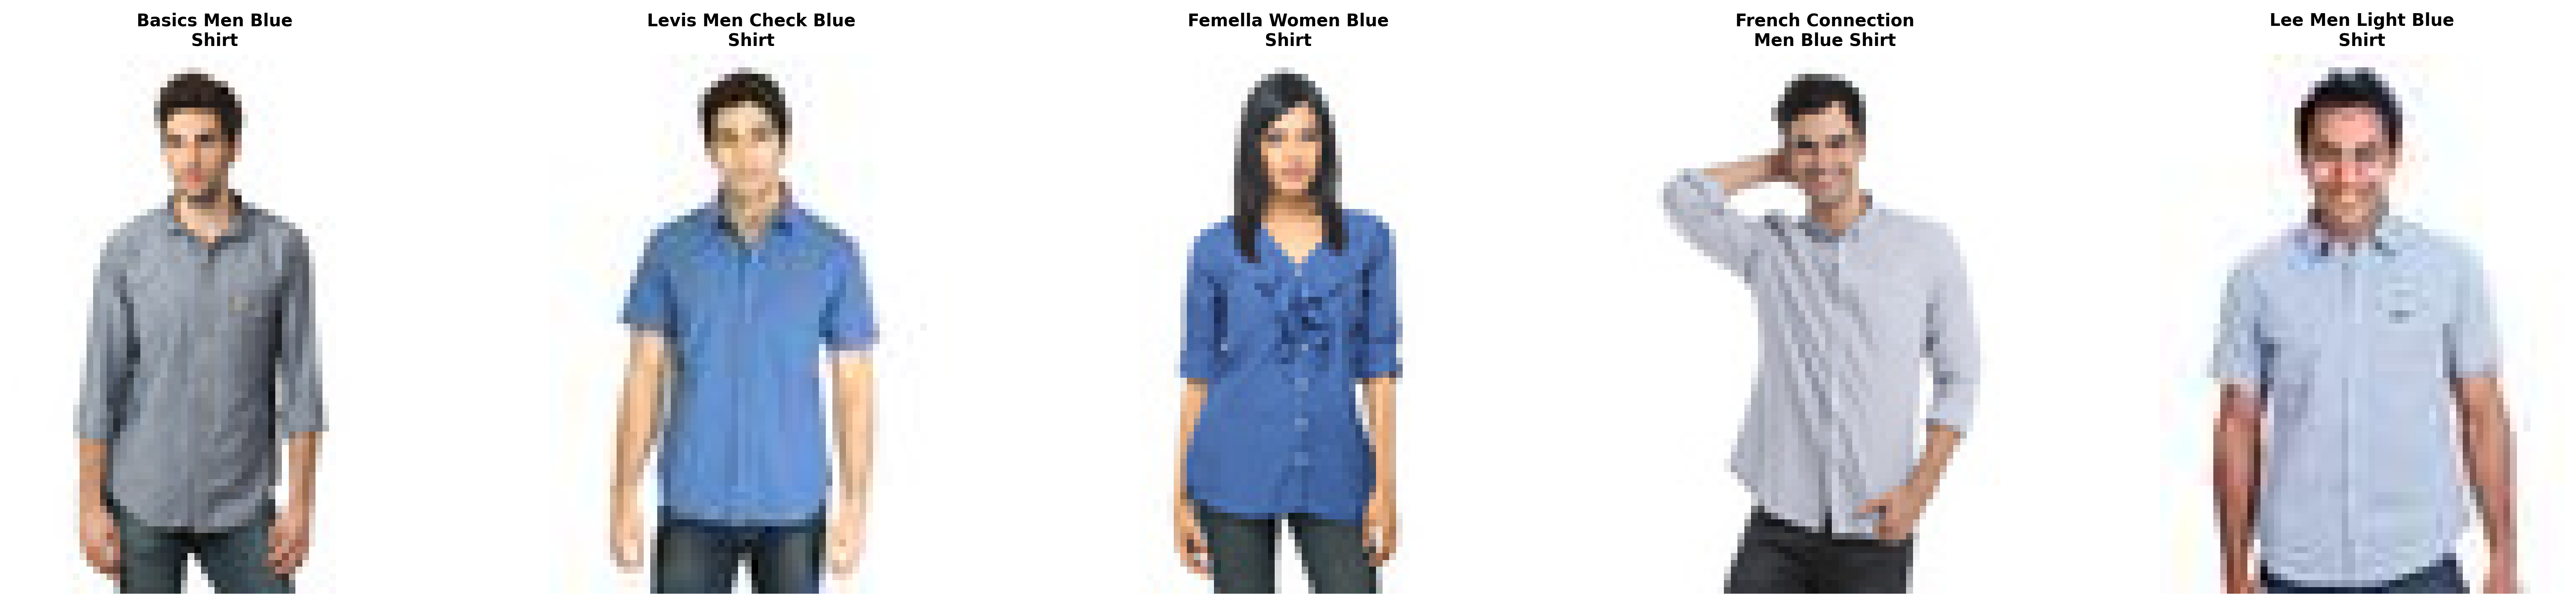

In [64]:

# ============================================
# TASK 3: Reverse Product Search
# ============================================

print("\n" + "="*50)
print("🔍 TASK 3: REVERSE PRODUCT SEARCH (CLIP semantic)")
print("="*50)

def search_products_semantic(query, top_k=5):
    inputs = processor(text=query, return_tensors="pt", truncation=True, max_length=77).to(device)
    with torch.no_grad():
        q_emb = model.get_text_features(**inputs)
        if hasattr(q_emb, 'pooler_output'):
            q_emb = q_emb.pooler_output
        elif isinstance(q_emb, tuple):
            q_emb = q_emb[0]
    q_emb = q_emb.cpu().numpy().flatten()
    q_emb = q_emb / np.linalg.norm(q_emb)
    sim = cosine_similarity([q_emb], embeddings).flatten()
    top_indices = sim.argsort()[::-1][:top_k]
    ids = []
    for i in top_indices:
        if sim[i] > 0.2:
            ids.append(df_subset.iloc[i]['id'])
    return ids

query = "blue casual shirt"
print(f"\n🔎 Query: '{query}'")
results = search_products_semantic(query, top_k=5)
if results:
    titles = [df_subset[df_subset['id']==pid].iloc[0]['productDisplayName'] for pid in results]
    subtitles = [df_subset[df_subset['id']==pid].iloc[0]['subCategory'] for pid in results]
    display_images(results, titles=titles, subtitles=subtitles, cols=5, figsize=(22,5))
else:
    print("No matches.")



**DYNAMIC INPUT**


⌨️ DYNAMIC INPUT
Product input: watch


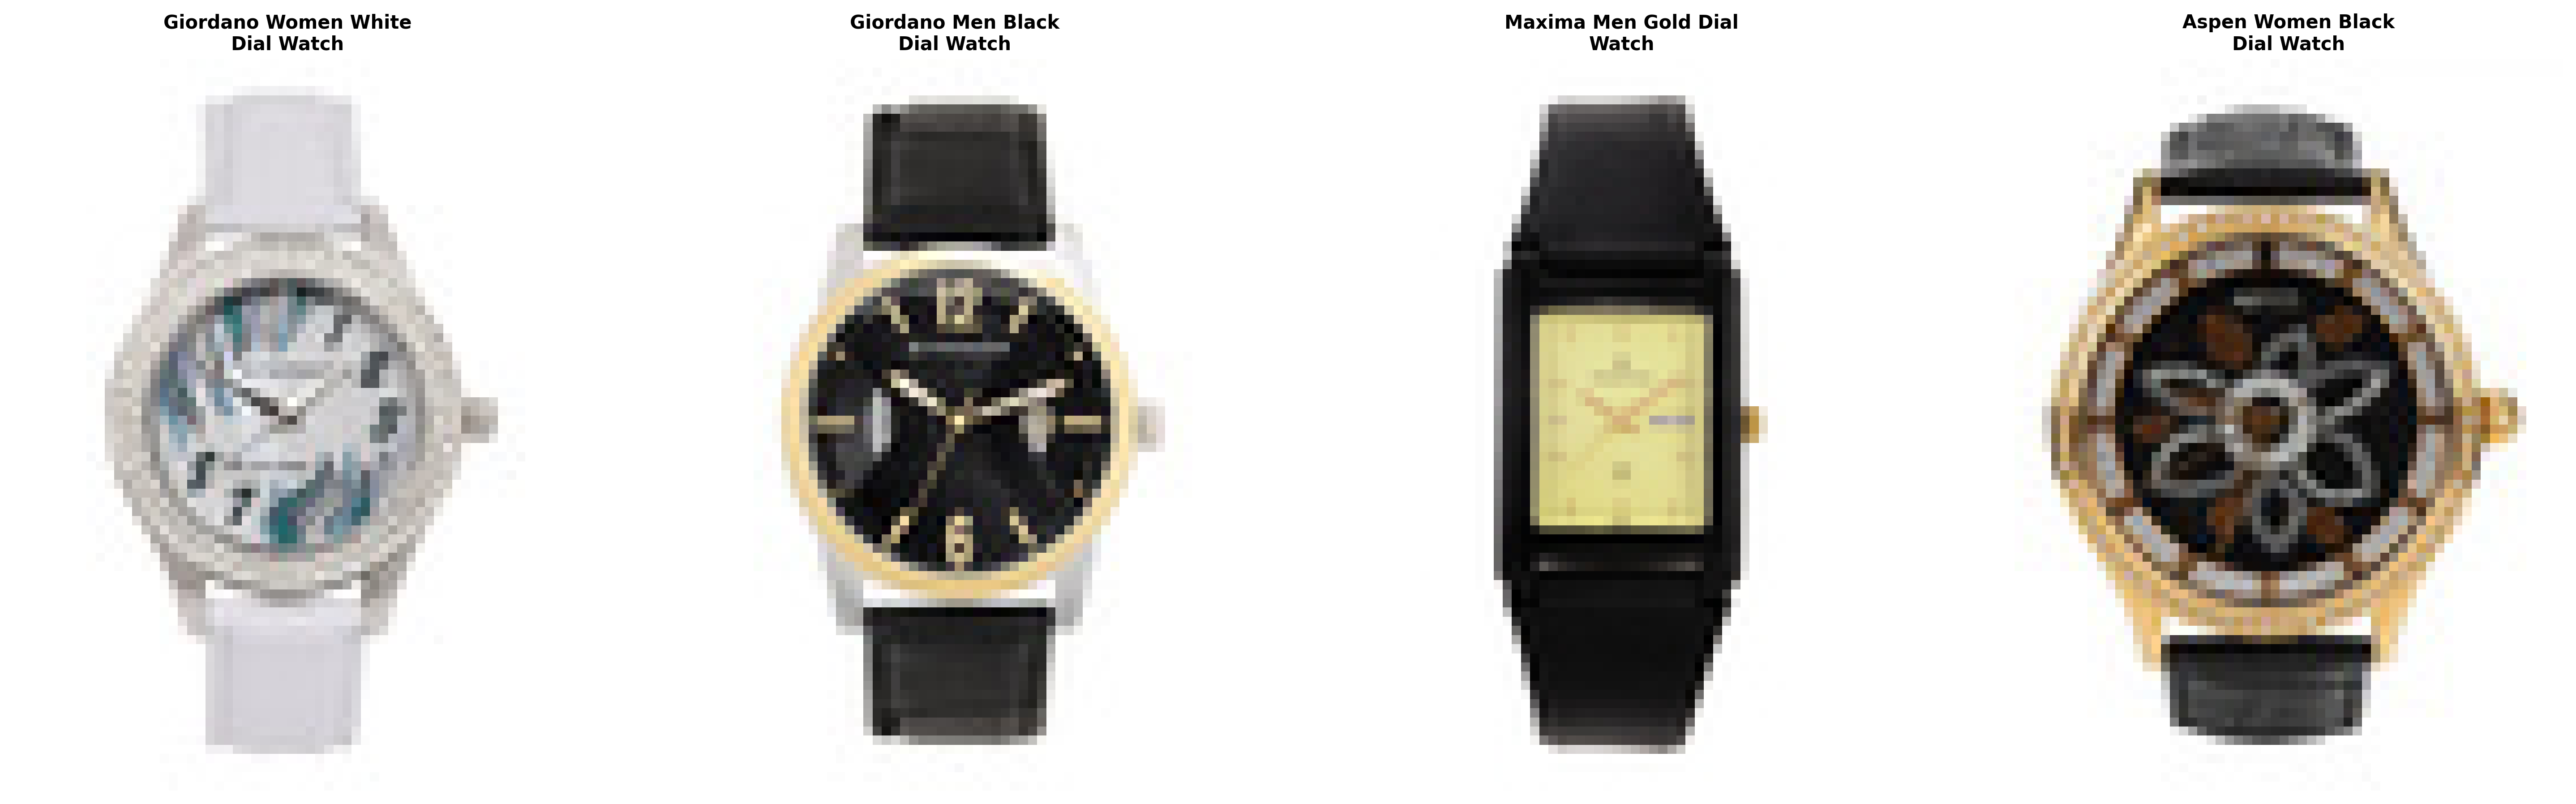

Query: black sneakers


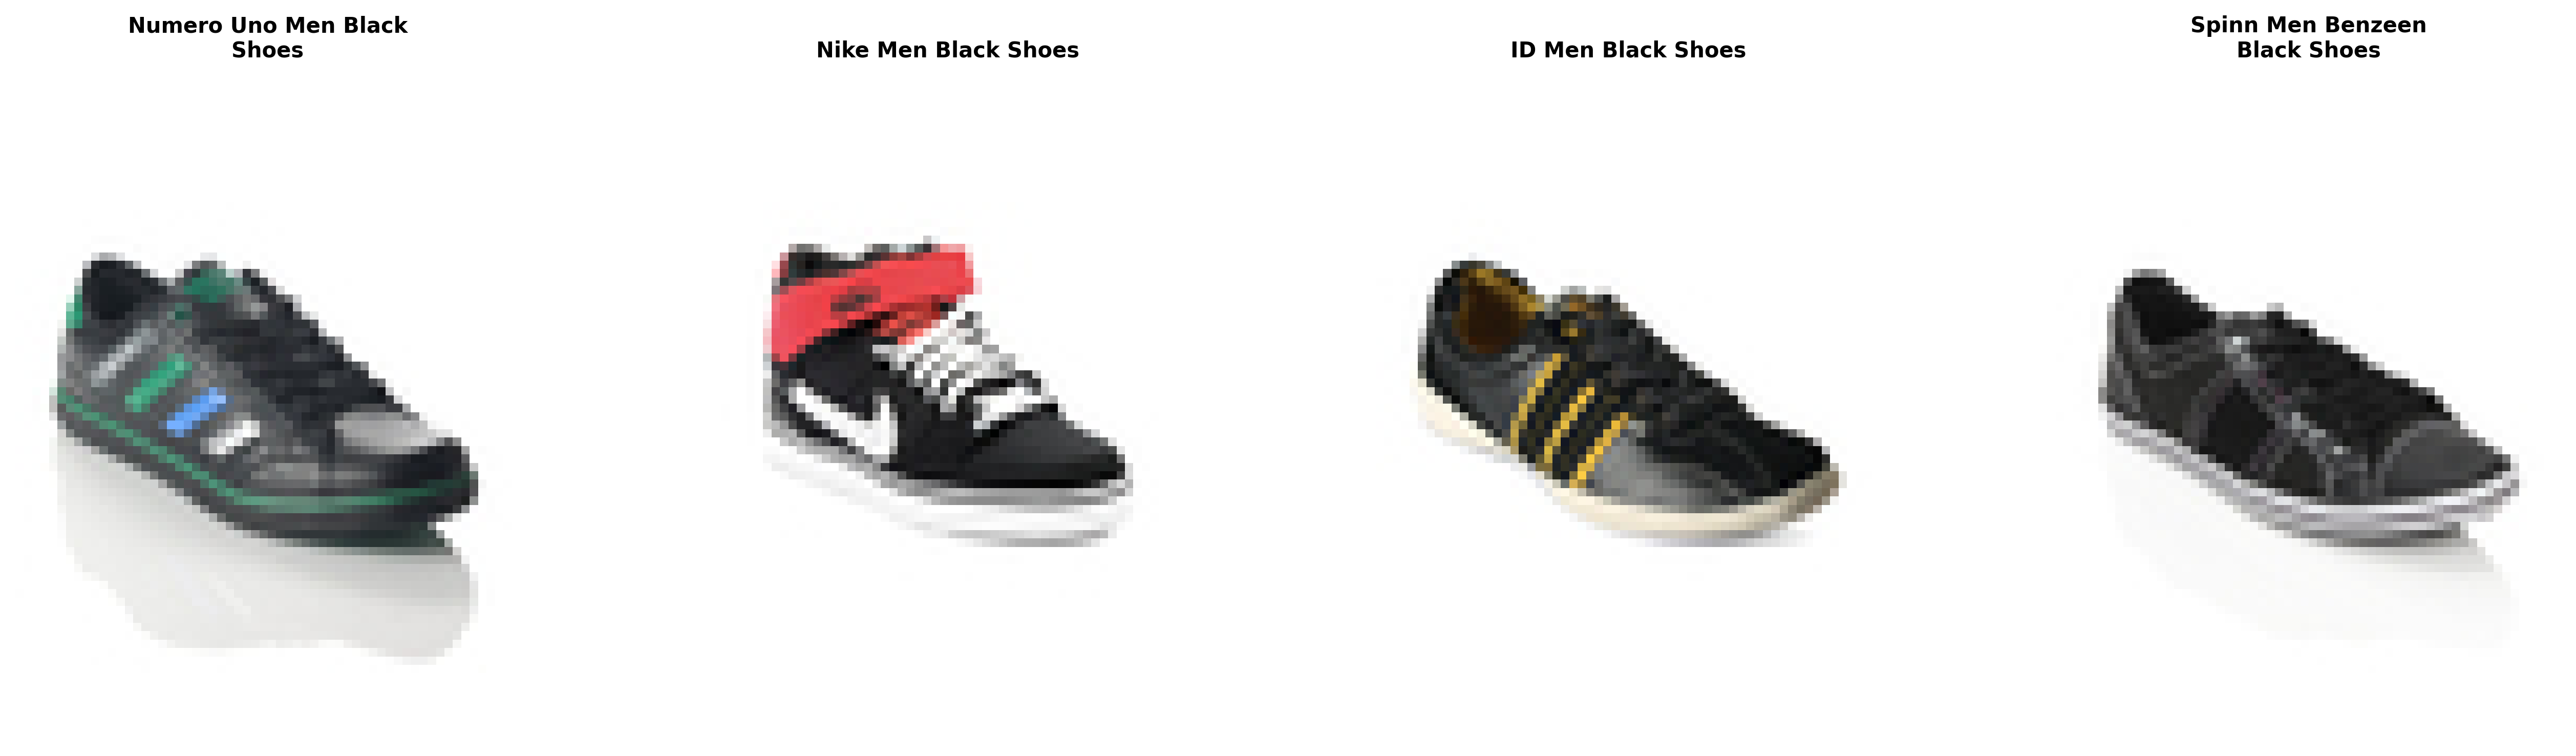

In [65]:
# ============================================
# DYNAMIC INPUT
# ============================================

print("\n" + "="*50)
print("⌨️ DYNAMIC INPUT")
print("="*50)

# Task 1: product name
product_input = "watch"  # replace with input() for interactive
print(f"Product input: {product_input}")
recs = recommend_complementary(product_input, top_k=4)
if recs:
    titles = [df_subset[df_subset['id']==pid].iloc[0]['productDisplayName'] for pid in recs]
    subtitles = [df_subset[df_subset['id']==pid].iloc[0]['subCategory'] for pid in recs]
    display_images(recs, titles=titles, subtitles=subtitles, cols=4, figsize=(20,6))

# Task 3: search query
query_input = "black sneakers"
print(f"Query: {query_input}")
results = search_products_semantic(query_input, top_k=4)
if results:
    titles = [df_subset[df_subset['id']==pid].iloc[0]['productDisplayName'] for pid in results]
    subtitles = [df_subset[df_subset['id']==pid].iloc[0]['subCategory'] for pid in results]
    display_images(results, titles=titles, subtitles=subtitles, cols=4, figsize=(18,5))
